In [1]:
pip install pandas


In [1]:
pip install seaborn matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
df= pd.read_csv("Telco-Customer-Churn.csv")
print(df.head())
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [4]:
df.columns.to_list()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [24]:
#df.isnull().sum()

df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df=df.dropna(subset=['TotalCharges'])
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7032, dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

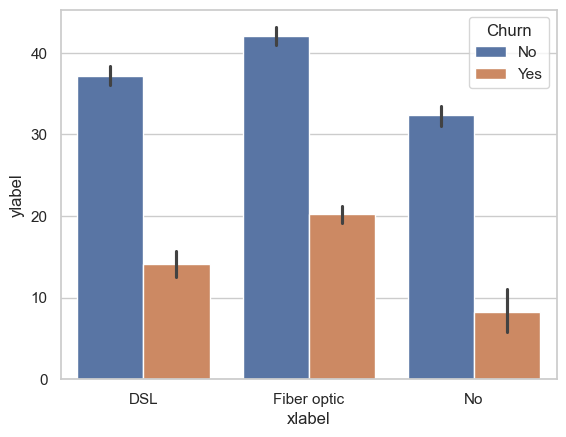

'\nHow to read this specific Bar Chart:\nThis chart shows the Average Tenure for each Internet Service type, split by Churn.\n\n1. Compare the Heights (The Averages)\nLook at Fiber optic: The blue bar is the tallest (~42 months). This tells you that Fiber optic customers who stay are your longest-tenured customers on average.\nLook at No (No Internet): The orange bar is the shortest (~8 months). This tells you that if a customer without internet service leaves, they usually leave very early on.\n2. Compare the Gaps (The Churn Impact)\nIn every category, the Blue bar (No) is much higher than the Orange bar (Yes).\nInterpretation: This confirms a universal truth in your data: customers who leave (Churn=Yes) always have significantly lower tenure than those who stay.\n3. The Black Lines on Top (Error Bars)\nThose little black lines are called Error Bars (or Confidence Intervals).\n\nShort line: The data is very consistent. Most people in that group have a tenure very close to the average.

In [10]:
#Bar plot
sns.set_theme(style="whitegrid")
sns.barplot(data=df,x='InternetService',y="tenure",hue='Churn')
plt.xlabel('xlabel')
plt.ylabel('ylabel')
plt.show()


"""
How to read this specific Bar Chart:
This chart shows the Average Tenure for each Internet Service type, split by Churn.

1. Compare the Heights (The Averages)
Look at Fiber optic: The blue bar is the tallest (~42 months). This tells you that Fiber optic customers who stay are your longest-tenured customers on average.
Look at No (No Internet): The orange bar is the shortest (~8 months). This tells you that if a customer without internet service leaves, they usually leave very early on.
2. Compare the Gaps (The Churn Impact)
In every category, the Blue bar (No) is much higher than the Orange bar (Yes).
Interpretation: This confirms a universal truth in your data: customers who leave (Churn=Yes) always have significantly lower tenure than those who stay.
3. The Black Lines on Top (Error Bars)
Those little black lines are called Error Bars (or Confidence Intervals).

Short line: The data is very consistent. Most people in that group have a tenure very close to the average.
Long line (like in the "No" Internet orange bar): There is more variety in the data. Some people left at 1 month, some at 15, so the average is less "exact."
"""


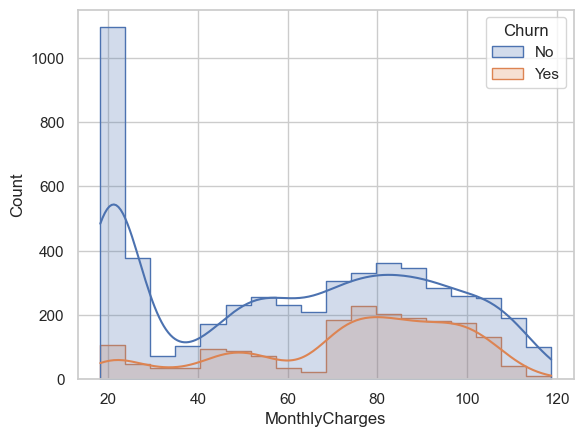

In [22]:
#Histogram
#plt.hist(df['Churn'],color='Red')
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',kde=True,element="step")
plt.show()

In [ ]:
"""
This is a perfect example of a Multi-modal Distribution (meaning it has multiple peaks). Here is how to read it and the insights you can take away:

1. How to read Skewness
Skewness tells you where the "Tail" of your data is pointing.

Right Skewed (Positive Skew): The mass of the data is on the left, but the "tail" stretches out to the right.
Example: Your Blue line (No Churn) is Right-Skewed. The massive peak is at $20, but it has a long tail stretching out toward $120.
Left Skewed (Negative Skew): The mass of the data is on the right, but the "tail" stretches out to the left.
Example: Your Orange line (Churn) is more Left-Skewed compared to the blue one. Its "mass" is between $70–$100, and it has a tail stretching back toward $20.
Rule of thumb: If the data is "leaning" to the left, it's Right-Skewed. If it's "leaning" to the right, it's Left-Skewed.

2. Summary of Insights from this Chart
A. The $20 "Safe Zone"
The tallest blue bar is at $20. Notice how the orange bar at that same spot is almost invisible.

Insight: Customers on your cheapest plans ($20/month) are extremely loyal. They almost never churn.
B. The $70–$100 "Churn Zone"
Look at where the orange curve is highest. It peaks around $80.

Insight: Churn is most common among customers paying Premium prices. This suggests that high-paying customers are the most price-sensitive or have the highest expectations. If they don't feel the service is worth $80+, they leave.
C. The "Hollow" Middle ($30–$60)
There is a "dip" in the middle for both groups.

Insight: Most of your customers are either on the very basic plan ($20) or the high-end plans ($70+). Very few people are in the "middle-tier" pricing.
Final Conclusion:
To reduce churn, the company shouldn't worry about the low-cost customers. They should focus on the value proposition for customers paying over $70, as that is where the vast majority of your revenue loss is happening.
"""

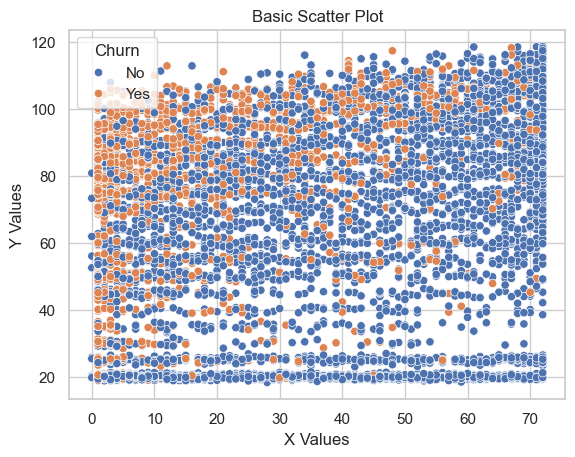

' \n1. The "Danger Zone" (Top-Left)\nNotice the high density of orange dots (Churn: Yes) in the top-left area.\n\nInterpretation: Customers who have high monthly bills (above 70) and low tenure (less than 20 months) are your highest churn risk. These are likely new customers who feel the service is too expensive or aren\'t seeing the value yet.\n2. The "Loyalty Zone" (Right Side)\nAs you move toward the right (high Tenure, 60+ months), the chart becomes almost entirely blue (Churn: No).\n\nInterpretation: Tenure is a strong predictor of loyalty. Once a customer stays past a certain point (around 20–30 months), they are very unlikely to leave, regardless of how much they are being charged.\n3. The "Economy Strip" (Bottom Line)\nLook at that horizontal line of dots right at the bottom (around 20 on the Y-axis). They are almost all blue.\n\nInterpretation: Customers on the cheapest plans (likely basic phone-only plans) have extremely high retention. They rarely churn, probably because the

In [13]:
#Correlation [Scatter plot]
sns.scatterplot(data=df,y='MonthlyCharges',x='tenure',hue='Churn')
plt.title("Basic Scatter Plot")
plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.show()

""" 
1. The "Danger Zone" (Top-Left)
Notice the high density of orange dots (Churn: Yes) in the top-left area.

Interpretation: Customers who have high monthly bills (above 70) and low tenure (less than 20 months) are your highest churn risk. These are likely new customers who feel the service is too expensive or aren't seeing the value yet.
2. The "Loyalty Zone" (Right Side)
As you move toward the right (high Tenure, 60+ months), the chart becomes almost entirely blue (Churn: No).

Interpretation: Tenure is a strong predictor of loyalty. Once a customer stays past a certain point (around 20–30 months), they are very unlikely to leave, regardless of how much they are being charged.
3. The "Economy Strip" (Bottom Line)
Look at that horizontal line of dots right at the bottom (around 20 on the Y-axis). They are almost all blue.

Interpretation: Customers on the cheapest plans (likely basic phone-only plans) have extremely high retention. They rarely churn, probably because the cost is so low it's not worth the effort to switch.
4. The High-Cost Stability (Top-Right)
Even at the very high end of charges (100+), if the tenure is high, the dots stay blue.

Interpretation: Premium customers (those paying the most) are willing to stay as long as they have been with the company for a long time. High prices don't necessarily cause churn if the relationship is established.
""" 

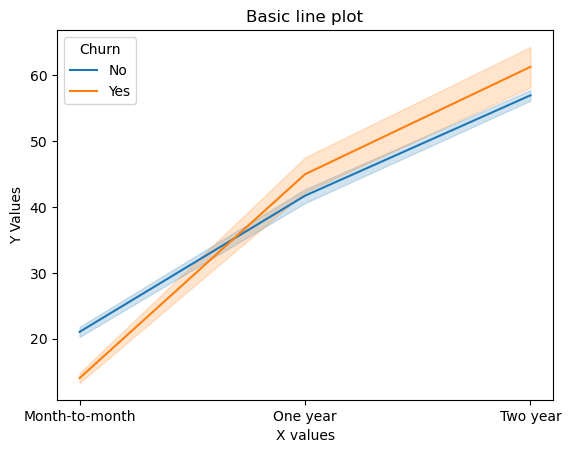

In [ ]:
#Line plot
sns.lineplot(data=df,y='tenure',x='Contract',hue='Churn')
plt.title("Basic line plot")
plt.xlabel("X values")
plt.ylabel("Y Values")
plt.show()

"""
1. The Month-to-Month Group (Left)
The blue line is higher than the orange line.
Interpretation: For month-to-month customers, those who stay (No Churn) have a higher average tenure (~22 months) than those who leave (~15 months). This makes sense—people in this group usually leave early.
2. The Two-Year Group (Right)
The orange line is now higher than the blue line.
Interpretation: This is a key insight! It tells us that if a customer on a 2-year contract does churn, they usually do it at the very end of their contract (after about 60+ months). They don't leave mid-way; they finish their long commitment and then decide to move on.
3. The Widening Shade (Right Side)
Notice how the orange shaded area gets very wide at "Two year."
Interpretation: There are very few people who have a 2-year contract and still churn. Because there are so few of them, the math is less certain, so the "shaded area" (confidence interval) grows larger to show that this average is based on a small sample size.
Summary:
This chart tells you that Contract Type is the biggest "anchor" for tenure. If you can get a customer onto a One-Year or Two-Year contract, you are almost guaranteed to keep them for at least 40 to 60 months before they even consider leaving.
"""
